# Stage 3: Outlier Detection & Treatment
**Member:** **M3 — IT25101145**
**Assigned Preprocessing Technique:** Log transformation + winsorisation (percentile capping) instead of row deletion
**Dataset:** [US Permanent Visa Applications](https://www.kaggle.com/datasets/jboysen/us-perm-visas) (US Department of Labor, via Kaggle)
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Pipeline Position:** Stage 3 of 6 (sequential)
**Input:** `results/outputs/stage2_encoded.parquet`
**Output:** `results/outputs/stage3_outliers_treated.parquet`

---
## 1. Explanation of the Technique

Outliers are values far from the bulk of the distribution - data-entry errors or genuine but extreme cases. Options:
1. **Z-score rule** (|z| > 3) - assumes normality.
2. **IQR rule** - flags values outside [Q1 - 1.5 IQR, Q3 + 1.5 IQR]; robust but deletes many rows on skewed data.
3. **Trimming** - delete the rows.
4. **Winsorisation / capping** - clip values to chosen percentiles; keeps every row.
5. **Log transformation** - compresses multiplicative (right-skewed) scales so extreme values stop dominating.

---
## 2. Justification for THIS Dataset Specifically

- After Stage 1 annualisation, offered wages still reach USD 1,000,000 and prevailing wages USD 981,672, while the middle 50% of jobs pay USD 73k-113k.
- **Employer size** spans 1 to 2.3 million employees - a multiplicative scale, so `log1p` is applied first; the same for `employer_filing_count` (0 to several thousand filings per employer).
- **Why not delete outliers?** The minority class lives in the unusual cases (very low wages, tiny employers). Deleting rows would remove exactly the denial signal the models need and would bias the train/test distribution. We therefore **cap at the train 1st / 99th percentiles** and keep 100% of the rows.
- The percentiles are computed on **train rows only** and applied to both splits.

### Why this must be Stage 3
- After Stage 2, so that only truly continuous columns are treated (one-hot and ordinal codes are left alone).
- Before Stage 4, so engineered ratios (offered / prevailing wage) are not built from extreme or mis-scaled values.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

# --- Project paths: search upward for the folder that contains data/raw ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

RAW_CSV = os.path.join(ROOT, 'data', 'raw', 'us_perm_visas.csv')
EXT_DIR = os.path.join(ROOT, 'data', 'external')
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
PLOT_DIR = os.path.join(ROOT, 'results', 'eda_visualizations')
LOG_DIR = os.path.join(ROOT, 'results', 'logs')
for _d in (OUT_DIR, PLOT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
TEST_SIZE = 0.20             # stratified 80/20 split; teammates use 5-fold CV on the train rows
DEV_SAMPLE = None            # e.g. 0.10 for a fast ~35k-row run; None = full dataset
EDA_ONLY_COLS = ['case_status', 'decision_date']                          # kept for EDA, dropped in S6
LEAKAGE_COLS = ['case_id', 'case_received_date', 'application_type', 'processing_days']  # must never reach a model
NON_FEATURE_COLS = EDA_ONLY_COLS + [TARGET, 'split']

REFERENCE_YEAR = 2016                                                     # last year in the dataset
S4_PASSTHROUGH = ['employer_state', 'job_info_work_state', 'agent_firm_name']  # raw columns kept by S2 for S4
SCALE_COLS = ['wage_offer_annual', 'pw_annual', 'wage_gap_annual', 'wage_to_pw_ratio',  # continuous / ordinal
              'employer_num_employees_log', 'employer_filing_count_log', 'employer_yr_estab', 'employer_age',
              'pw_level', 'edu_worker', 'edu_required', 'edu_gap']

# --- Reference tables (data/external) ---
_states = pd.read_csv(os.path.join(EXT_DIR, 'us_states.csv'))
STATE_LOOKUP = {**dict(zip(_states['state_name'], _states['state_code'])),
                **dict(zip(_states['state_code'], _states['state_code']))}
STATE_REGION = dict(zip(_states['state_code'], _states['census_region']))
VALID_SOC = set(pd.read_csv(os.path.join(EXT_DIR, 'soc_major_groups.csv'), dtype=str)['soc_major_group'])
_naics = pd.read_csv(os.path.join(EXT_DIR, 'naics_sectors.csv'), dtype=str)
VALID_NAICS = set(_naics['naics_2digit'])
NAICS_SECTOR_KEY = dict(zip(_naics['naics_2digit'], _naics['sector_key']))

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')

Project root: /Users/jathushansundararasu/Desktop/us_prem_visa


In [2]:
# ==============================================================================
# STAGE 3: Outlier Treatment (M3)
# ==============================================================================
WINSOR_COLS = ['wage_offer_annual', 'pw_annual', 'employer_num_employees_log', 'employer_filing_count_log',
               'employer_yr_estab']
WINSOR_LIMITS = (0.01, 0.99)


def stage3_outlier_treatment(df, plot_dir=PLOT_DIR, out_dir=OUT_DIR, show_plot=False):
    """
    - log1p for the extremely right-skewed counts (employer size, employer filing count).
    - Winsorise at the TRAIN 1st / 99th percentiles. No rows are deleted: unusual applications are
      exactly where denials concentrate, so trimming would throw away minority-class signal.
    """
    d = df.copy()
    train = d['split'].eq('train')
    raw = d[['wage_offer_annual', 'pw_annual', 'employer_num_employees']].copy()

    d['employer_num_employees_log'] = np.log1p(d['employer_num_employees']).astype('float32')
    d['employer_filing_count_log'] = np.log1p(d['employer_filing_count']).astype('float32')
    d = d.drop(columns=['employer_num_employees', 'employer_filing_count'])

    caps = []
    for col in WINSOR_COLS:
        lo, hi = d.loc[train, col].quantile(list(WINSOR_LIMITS))
        clipped = ((d[col] < lo) | (d[col] > hi)).mean() * 100
        d[col] = d[col].clip(lo, hi).astype('float32')
        caps.append({'column': col, 'p01_train': lo, 'p99_train': hi, 'pct_rows_capped': round(clipped, 2)})
    caps = pd.DataFrame(caps)
    if out_dir:
        caps.to_csv(os.path.join(out_dir, 'outlier_caps.csv'), index=False)

    if plot_dir:
        fig, axes = plt.subplots(2, 3, figsize=(18, 8))
        plt.subplots_adjust(hspace=0.45, wspace=0.25)
        panels = [('wage_offer_annual', 'wage_offer_annual', 'Offered wage (USD/yr)'),
                  ('pw_annual', 'pw_annual', 'Prevailing wage (USD/yr)'),
                  ('employer_num_employees', 'employer_num_employees_log', 'Employer size')]
        for j, (raw_col, new_col, label) in enumerate(panels):
            axes[0, j].boxplot(raw[raw_col], vert=False, patch_artist=True, boxprops=dict(facecolor='#e74c3c'))
            axes[0, j].set_title(f'Raw {label}\nmax = {raw[raw_col].max():,.0f}', fontweight='bold')
            axes[1, j].boxplot(d[new_col], vert=False, patch_artist=True, boxprops=dict(facecolor='#2ecc71'))
            suffix = 'log1p + ' if new_col.endswith('_log') else ''
            axes[1, j].set_title(f'Treated: {suffix}winsorised P1-P99 (train)', fontweight='bold')
            axes[0, j].set_yticks([])
            axes[1, j].set_yticks([])
            for ax in (axes[0, j], axes[1, j]) if j < 2 else (axes[0, j],):
                ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:,.0f}k'))
        plt.suptitle('m3: Outlier treatment - raw vs treated (no rows removed)', fontsize=14, fontweight='bold', y=1.03)
        plt.savefig(f'{plot_dir}/m3_outlier_boxplots.png', dpi=200, bbox_inches='tight')
        plt.show() if show_plot else plt.close()
    print(f'[Stage 3] caps (train percentiles):\n{caps.to_string(index=False)}')
    return d

Loaded Stage 2 data: 354,849 rows x 106 columns


/var/folders/0_/_xwgtpx52d9b1727yds80cq80000gn/T/ipykernel_65042/769636101.py:40: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, j].boxplot(raw[raw_col], vert=False, patch_artist=True, boxprops=dict(facecolor='#e74c3c'))
/var/folders/0_/_xwgtpx52d9b1727yds80cq80000gn/T/ipykernel_65042/769636101.py:42: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, j].boxplot(d[new_col], vert=False, patch_artist=True, boxprops=dict(facecolor='#2ecc71'))
/var/folders/0_/_xwgtpx52d9b1727yds80cq80000gn/T/ipykernel_65042/769636101.py:40: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, j].boxplot(raw[raw_col], vert=False, patch_artist=True, boxprops=dict(f

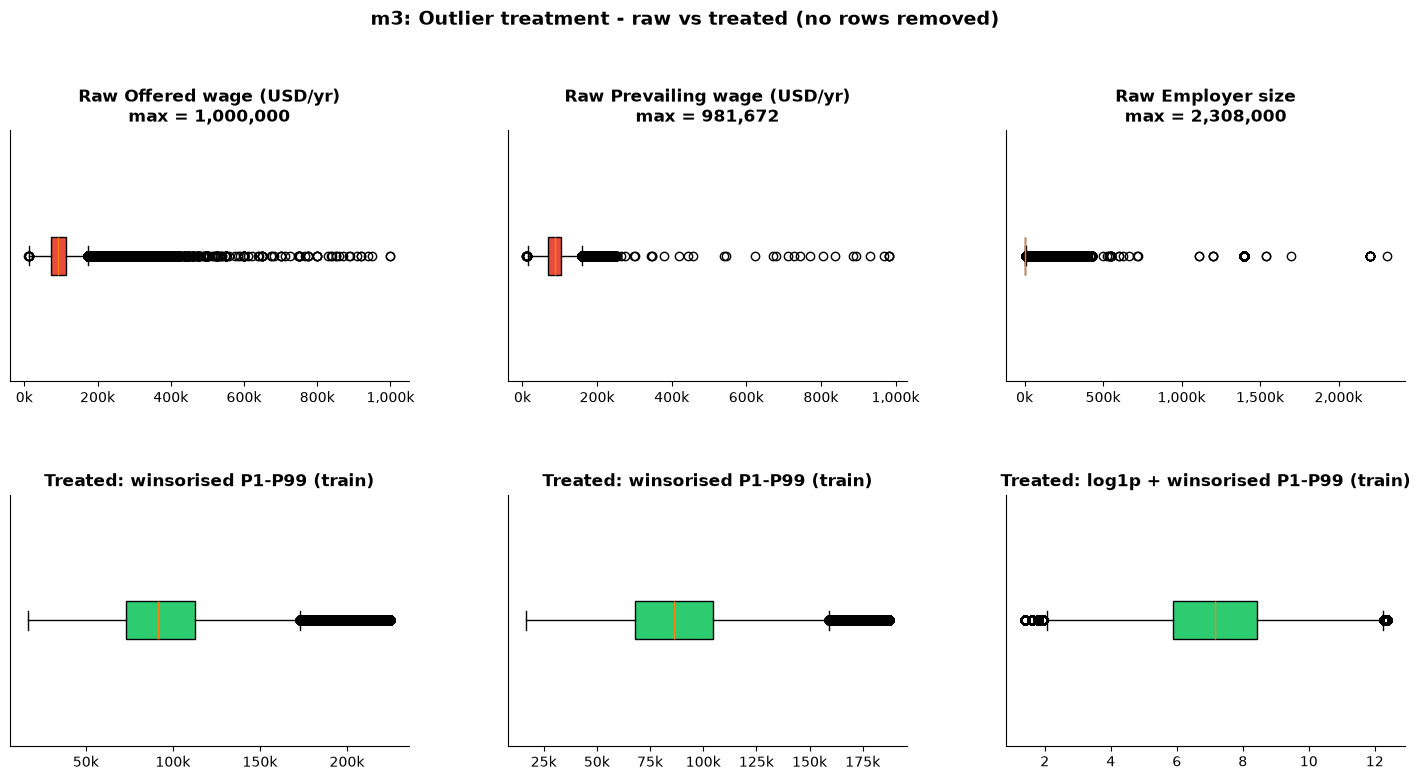

[Stage 3] caps (train percentiles):
                    column    p01_train     p99_train  pct_rows_capped
         wage_offer_annual 16869.000000 225000.000000             1.95
                 pw_annual 16848.000000 187199.000000             1.64
employer_num_employees_log     1.386294     12.365633             1.80
 employer_filing_count_log     0.000000      9.167120             0.66
         employer_yr_estab  1853.000000   2013.000000             1.97


Saved Stage 3 output: 354,849 rows x 106 columns


In [3]:
# 1. Load Stage 2 output and treat outliers (+ EDA plot m3)
df_2 = pd.read_parquet(os.path.join(OUT_DIR, 'stage2_encoded.parquet'))
print(f'Loaded Stage 2 data: {df_2.shape[0]:,} rows x {df_2.shape[1]} columns')
df_3 = stage3_outlier_treatment(df_2, show_plot=True)
df_3.to_parquet(os.path.join(OUT_DIR, 'stage3_outliers_treated.parquet'), index=False)
print(f'Saved Stage 3 output: {df_3.shape[0]:,} rows x {df_3.shape[1]} columns')

In [4]:
# 2. Verification ("done when" checks)
assert len(df_3) == len(df_2), 'rows were removed'
caps = pd.read_csv(os.path.join(OUT_DIR, 'outlier_caps.csv'))
for r in caps.itertuples():
    assert df_3[r.column].between(r.p01_train - 1e-3, r.p99_train + 1e-3).all(), f'{r.column} outside caps'
print(f'Rows kept: {len(df_3):,} of {len(df_2):,} (100%)')
print('All Stage 3 checks passed.')

Rows kept: 354,849 of 354,849 (100%)
All Stage 3 checks passed.


## 3. EDA Interpretation & Findings

1. **Heavy right tails:** the raw box plots are compressed against the left edge by a handful of extreme values (offered wage max USD 1,000,000, employer size max 2,308,000).
2. **Capping is light-touch:** only 1.95% of offered wages (cap USD 16,869-225,000), 1.64% of prevailing wages (USD 16,848-187,199), 1.80% of employer sizes and 1.97% of founding years (1853-2013) are capped.
3. **Log scale reveals structure:** `log1p(employer size)` turns a single spike into a readable distribution (median 1,269 employees), useful for linear, distance-based and neural models.
4. **Zero data loss:** all 354,849 applications and all 24,524 denials are retained for Stage 4.